In [ ]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.datasets import make_classification

In [3]:
df = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')


In [ ]:
df["catalog_content"] = df["catalog_content"].fillna("").astype(str)
# Create categorical target: price_class (Low / Medium / High)
df["price_class"] = pd.qcut(df["price"], q=3, labels=["Low", "Medium", "High"])
print("Target distribution:\n", df["price_class"].value_counts())

Target distribution:
 price_class
Low       25393
High      24952
Medium    24655
Name: count, dtype: int64


In [5]:
# Extract numeric text-based features
def make_features(s):
    s = s.fillna("").astype(str)
    return pd.DataFrame({
        "text_length": s.str.len(),
        "word_count": s.str.split().map(len),
        "digits": s.str.count(r"\d"),
        "commas": s.str.count(","),
        "periods": s.str.count("\.")
    })

X = make_features(df["catalog_content"])
X["sample_id"] = df["sample_id"].astype(float)# Ensure sample_id is numeric

y = df["price_class"]# Target variable

print("Feature sample:\n", X.head())


<>:9: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:9: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
/var/folders/hg/6k2xrn0x1hxd4zlz_g32w19h0000gn/T/ipykernel_36055/2438596212.py:9: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  "periods": s.str.count("\.")


Feature sample:
    text_length  word_count  digits  commas  periods  sample_id
0           91          18       6       1        1    33127.0
1          511          80      17       4        1   198967.0
2          328          59      12       2        2   261251.0
3         1318         211      17      14        9    55858.0
4          155          28      13       2        5   292686.0


In [6]:
le=LabelEncoder()
y_encoded = le.fit_transform(y)

# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Train shape:", X_train.shape, "Val shape:", X_val.shape)

Train shape: (60000, 6) Val shape: (15000, 6)


✅ Validation Accuracy: 44.81%
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.35      0.41      4990
           1       0.44      0.75      0.55      5079
           2       0.40      0.24      0.30      4931

    accuracy                           0.45     15000
   macro avg       0.45      0.45      0.42     15000
weighted avg       0.45      0.45      0.42     15000



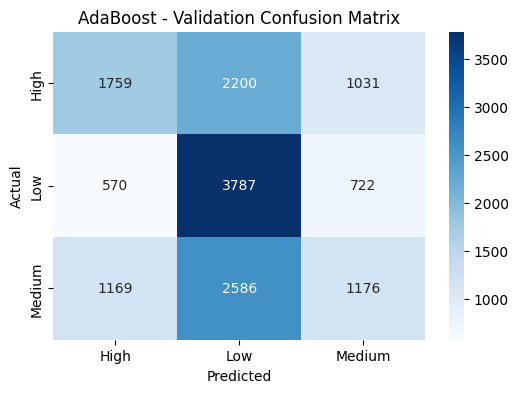

💾 Saved AdaBoost model to models/adaboost_price_classifier.joblib
💾 Saved test predictions to 'test_adaboost_predictions.csv'
💾 Saved test predictions to 'test_adaboost_predictions.csv'


In [7]:
# Train AdaBoost on the categorical price target and evaluate
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# Proper AdaBoost classifier (use base estimator defaults or provide one)
clf = AdaBoostClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Validation evaluation
y_val_pred = clf.predict(X_val)
acc = accuracy_score(y_val, y_val_pred)
print(f"✅ Validation Accuracy: {acc*100:.2f}%")
print("Classification Report:\n", classification_report(y_val, y_val_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_val, y_val_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("AdaBoost - Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save model
joblib.dump(clf, "models/adaboost_price_classifier.joblib")
print("💾 Saved AdaBoost model to models/adaboost_price_classifier.joblib")

# Predict on test set and save
# Prepare test features (ensure df_test exists and sample_id numeric)
if 'df_test' not in globals():
    df_test = pd.read_csv('test.csv')

df_test['catalog_content'] = df_test['catalog_content'].fillna('').astype(str)
X_test = make_features(df_test['catalog_content'])
X_test['sample_id'] = df_test['sample_id'].astype(float)

y_test_pred = clf.predict(X_test)
# convert encoded labels back to original string labels
if 'le' in globals():
    try:
        y_test_pred_labels = le.inverse_transform(y_test_pred)
    except Exception:
        y_test_pred_labels = y_test_pred
else:
    y_test_pred_labels = y_test_pred

df_test['predicted_price_class'] = y_test_pred_labels
df_test.to_csv('test_adaboost_predictions.csv', index=False)
print("💾 Saved test predictions to 'test_adaboost_predictions.csv'")

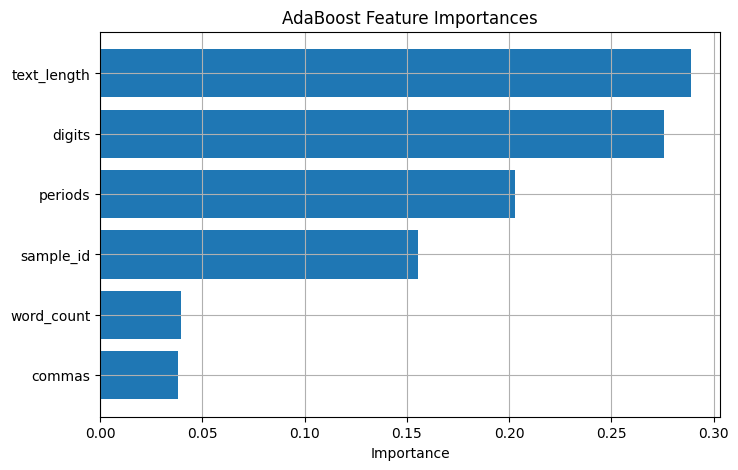

In [10]:
# Plot feature importances for the trained classifier (AdaBoost)
features = X.columns.tolist()

if hasattr(clf, "feature_importances_"):
    importances = clf.feature_importances_
    order = np.argsort(importances)
    plt.figure(figsize=(8,5))
    plt.barh([features[i] for i in order], importances[order])
    plt.xlabel("Importance")
    plt.title("AdaBoost Feature Importances")
    plt.grid(True)
    plt.show()
else:
    print("The trained model does not expose 'feature_importances_'. Use model-specific plotting or inspect coefficients.")